Text(0.5, 1.0, 'Petal length')

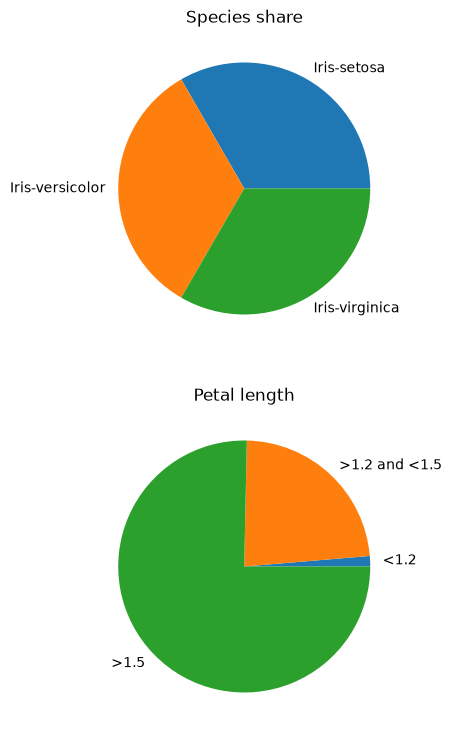

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# with open('iris_data.csv') as f:
#     f = pd.read_csv('iris_data.csv')
# species = set(f.Species)
# species_count = {}
# for i in f.Species:
#     species_count[i] = f.Species.count(i)

f = pd.read_csv('iris_data.csv')


species_count = f.Species.value_counts(normalize=True).to_dict()


petal_count = f.PetalLengthCm.value_counts().to_dict()
petal_pc = {'<1.2' : 0, '>1.2 and <1.5' : 0, '>1.5' : 0}
for key, value in petal_count.items():
    if key < 1.2:
        petal_pc['<1.2'] += value
    elif key >= 1.2 and key <= 1.5:
        petal_pc['>1.2 and <1.5'] += value
    else:
        petal_pc['>1.5'] += value



total = sum(petal_pc.values())
petal_pc_share = {}
for key, value in petal_pc.items():
    petal_pc_share[key] = value / total

fig = plt.figure(figsize = (16,9))
ax1 = fig.add_subplot(211)
ax2 = fig.add_subplot(212) 

# ax1.pie([species_count['Iris-setosa'],species_count['Iris-versicolor'], species_count['Iris-virginica']], labels = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])
ax1.pie(species_count.values(), labels=species_count.keys())
ax1.set_title('Species share')

# ax2.pie([petal_pc_share['<1.2'], petal_pc_share['>1.2 and <1.5'], petal_pc_share['>1.5']], labels = ['<1.2','>1.2 and <1.5','>1.5'])
ax2.pie(petal_pc_share.values(), labels=petal_pc_share.keys())
ax2.set_title('Petal length')
